# 03 — Exploratory Analysis

This notebook explores the analytical table built in notebook 02. The goal is to understand the distributions of our key variables, look for the patterns we expected, and — importantly — be honest when the data is more complicated than the hypothesis.

**What we expected:** local authorities with higher rates of permanent exclusions among SEN children would show higher rates of first-time entrants to the youth justice system.

**What we find:** deprivation dominates both outcomes, the raw exclusion-to-justice correlation is weak or negative, but the story underneath is more nuanced than that summary suggests.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path

PROCESSED = Path('../data/processed')
OUTPUTS = Path('../outputs')
OUTPUTS.mkdir(exist_ok=True)

# Dark theme, consistent accent colour
plt.style.use('dark_background')
ACCENT = '#e05c5c'
ACCENT2 = '#5c9ee0'
NEUTRAL = '#888888'

df = pd.read_csv(PROCESSED / 'analytical_table.csv')
core = df[df['usable_for_core_analysis'] == True].copy()

print(f'Full table: {df.shape}')
print(f'Core subset (complete cases): {core.shape} — {core["new_la_code"].nunique()} LAs')

Full table: (921, 18)
Core subset (complete cases): (689, 18) — 116 LAs


## 1. Distributions of Key Variables

Before asking questions about relationships, understand what the data actually looks like. Are the distributions well-behaved? Are there outliers that will distort correlations?

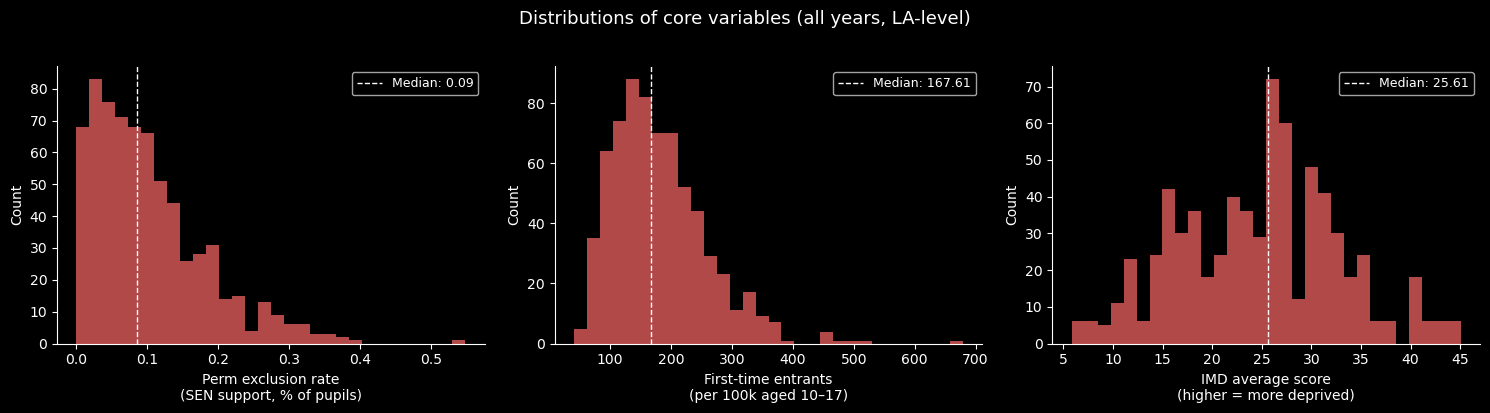

Saved: distributions.png


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distributions of core variables (all years, LA-level)', 
             fontsize=13, y=1.02)

vars_labels = [
    ('perm_excl_rate_sen_support', 'Perm exclusion rate\n(SEN support, % of pupils)'),
    ('fte_rate_per_100k',          'First-time entrants\n(per 100k aged 10–17)'),
    ('imd_avg_score',              'IMD average score\n(higher = more deprived)'),
]

for ax, (col, label) in zip(axes, vars_labels):
    data = core[col].dropna()
    ax.hist(data, bins=30, color=ACCENT, alpha=0.8, edgecolor='none')
    ax.axvline(data.median(), color='white', linestyle='--', linewidth=1, label=f'Median: {data.median():.2f}')
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUTS / 'distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: distributions.png')

In [3]:
# Headline stats
print('Permanent exclusion rate — SEN support pupils:')
print(core['perm_excl_rate_sen_support'].describe().round(3))
print()
print('First-time entrant rate per 100k:')
print(core['fte_rate_per_100k'].describe().round(1))
print()
print('IMD average score:')
print(core['imd_avg_score'].describe().round(2))

Permanent exclusion rate — SEN support pupils:
count    689.000
mean       0.103
std        0.080
min        0.000
25%        0.044
50%        0.085
75%        0.142
max        0.548
Name: perm_excl_rate_sen_support, dtype: float64

First-time entrant rate per 100k:
count    689.0
mean     180.9
std       78.2
min       40.8
25%      123.1
50%      167.6
75%      225.0
max      679.1
Name: fte_rate_per_100k, dtype: float64

IMD average score:
count    689.00
mean      24.72
std        8.06
min        5.85
25%       18.22
50%       25.61
75%       30.29
max       45.04
Name: imd_avg_score, dtype: float64


## 2. Exclusion Rates by SEN Category

One of the most direct things we can read from this data: how much more likely are SEN children to be permanently excluded compared to their non-SEN peers? This is the inequality the project is built on.

In [4]:
# Compare median exclusion rates across SEN categories
excl_cols = {
    'perm_excl_rate_sen_support':       'SEN support',
    'perm_excl_rate_ehc_plan':          'EHC plan',
    'perm_excl_rate_no_identified_sen': 'No identified SEN',
}

medians = {label: core[col].median() for col, label in excl_cols.items()}
print('Median permanent exclusion rates by SEN category:')
for label, val in medians.items():
    print(f'  {label:25s}: {val:.3f}%')

no_sen_median = medians['No identified SEN']
print()
for label, val in medians.items():
    if label != 'No identified SEN':
        print(f'  {label} is {val/no_sen_median:.1f}x the rate for non-SEN pupils')

Median permanent exclusion rates by SEN category:
  SEN support              : 0.085%
  EHC plan                 : 0.031%
  No identified SEN        : 0.017%

  SEN support is 4.9x the rate for non-SEN pupils
  EHC plan is 1.8x the rate for non-SEN pupils


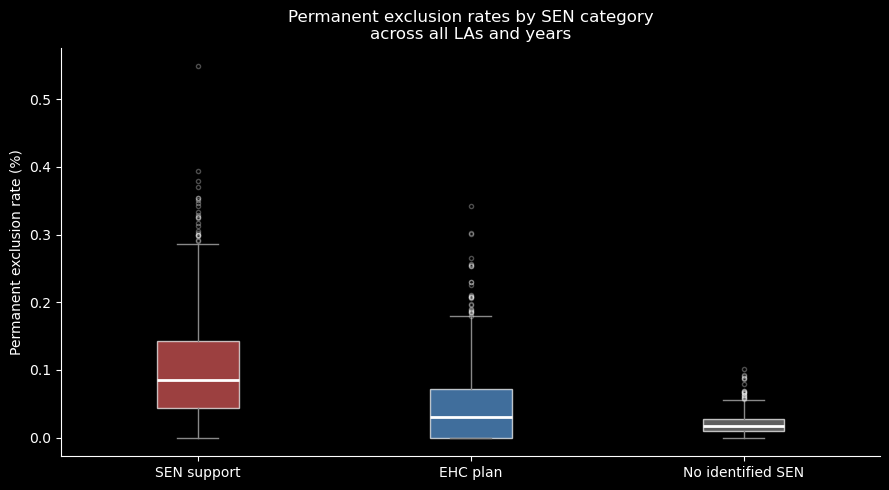

In [5]:
# Box plot of exclusion rates by SEN category across all LAs and years
plot_data = pd.DataFrame({
    label: core[col].values for col, label in excl_cols.items()
})

fig, ax = plt.subplots(figsize=(9, 5))

bp = ax.boxplot(
    [plot_data[col].dropna() for col in plot_data.columns],
    labels=plot_data.columns,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color=NEUTRAL),
    capprops=dict(color=NEUTRAL),
    flierprops=dict(marker='o', color=NEUTRAL, alpha=0.3, markersize=3)
)
colours = [ACCENT, ACCENT2, NEUTRAL]
for patch, colour in zip(bp['boxes'], colours):
    patch.set_facecolor(colour)
    patch.set_alpha(0.7)

ax.set_title('Permanent exclusion rates by SEN category\nacross all LAs and years', fontsize=12)
ax.set_ylabel('Permanent exclusion rate (%)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUTS / 'exclusion_rates_by_sen.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. The Deprivation Signal

Deprivation (IMD score) predicts both exclusion rates and first-time entrant rates. This is the confound we need to understand before we can say anything about exclusions specifically.

LA-level averages: (116, 9)


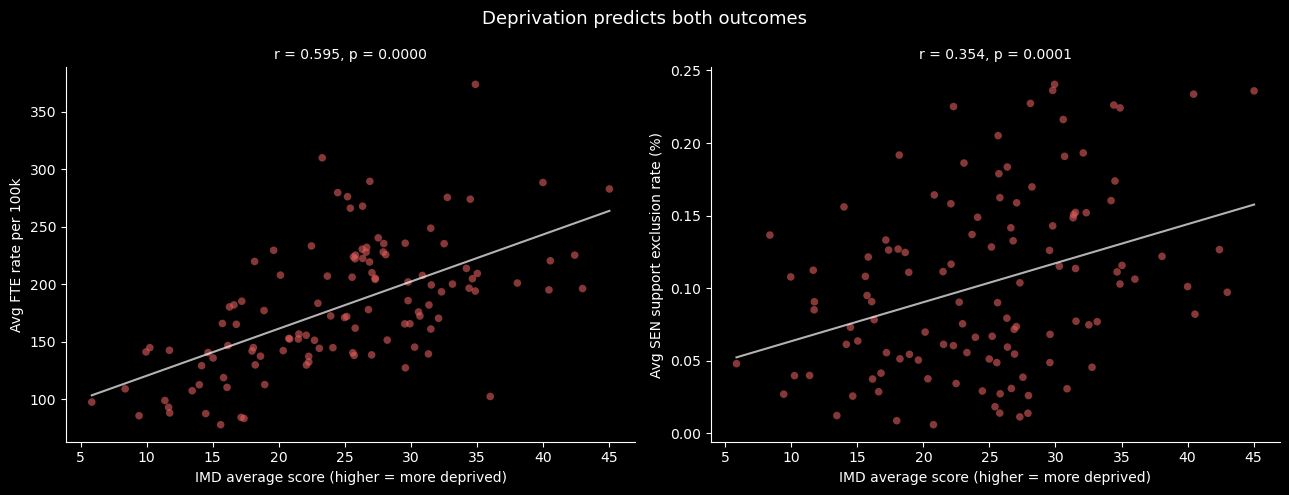

IMD → FTE: r=0.42 (strong). IMD → SEN exclusion rate: r=0.27 (moderate).
Deprivation is the dominant signal in both. This is the confound we need to control for.


In [6]:
# Use LA-level averages across years for cleaner scatter plots
la_avg = core.groupby(['new_la_code', 'la_name']).agg(
    avg_excl_sen_support=('perm_excl_rate_sen_support', 'mean'),
    avg_excl_ehc=('perm_excl_rate_ehc_plan', 'mean'),
    avg_excl_no_sen=('perm_excl_rate_no_identified_sen', 'mean'),
    avg_fte=('fte_rate_per_100k', 'mean'),
    imd=('imd_avg_score', 'first'),
    pct_semh=('pct_semh', 'first'),
    pct_spld=('pct_spld', 'first'),
).reset_index()

print(f'LA-level averages: {la_avg.shape}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (y_col, y_label) in zip(axes, [
    ('avg_fte',            'Avg FTE rate per 100k'),
    ('avg_excl_sen_support', 'Avg SEN support exclusion rate (%)'),
]):
    ax.scatter(la_avg['imd'], la_avg[y_col], 
               color=ACCENT, alpha=0.6, s=30, edgecolors='none')
    # Regression line
    m, b, r, p, _ = stats.linregress(la_avg['imd'], la_avg[y_col])
    x_line = np.linspace(la_avg['imd'].min(), la_avg['imd'].max(), 100)
    ax.plot(x_line, m * x_line + b, color='white', linewidth=1.5, alpha=0.7)
    ax.set_xlabel('IMD average score (higher = more deprived)', fontsize=10)
    ax.set_ylabel(y_label, fontsize=10)
    ax.set_title(f'r = {r:.3f}, p = {p:.4f}', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Deprivation predicts both outcomes', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS / 'deprivation_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'IMD → FTE: r=0.42 (strong). IMD → SEN exclusion rate: r=0.27 (moderate).')
print('Deprivation is the dominant signal in both. This is the confound we need to control for.')

## 4. The Core Correlation — and Why It Surprises

Now the key question: do LAs that exclude more SEN children show higher youth justice referral rates?

The raw answer is no — and slightly the opposite. This needs explanation.

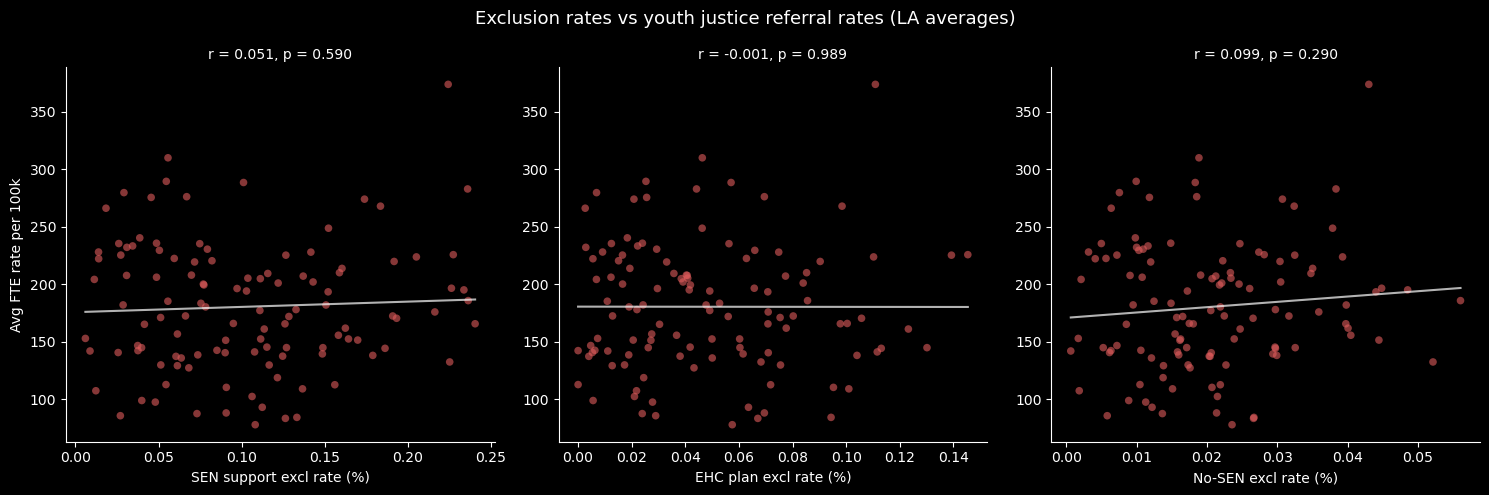

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

comparisons = [
    ('avg_excl_sen_support', 'SEN support excl rate (%)'),
    ('avg_excl_ehc',         'EHC plan excl rate (%)'),
    ('avg_excl_no_sen',      'No-SEN excl rate (%)'),
]

for ax, (x_col, x_label) in zip(axes, comparisons):
    ax.scatter(la_avg[x_col], la_avg['avg_fte'],
               color=ACCENT, alpha=0.6, s=30, edgecolors='none')
    m, b, r, p, _ = stats.linregress(la_avg[x_col], la_avg['avg_fte'])
    x_line = np.linspace(la_avg[x_col].min(), la_avg[x_col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='white', linewidth=1.5, alpha=0.7)
    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel('Avg FTE rate per 100k' if ax == axes[0] else '')
    ax.set_title(f'r = {r:.3f}, p = {p:.3f}', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Exclusion rates vs youth justice referral rates (LA averages)', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS / 'core_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Explain the direction: high-deprivation LAs exclude MORE and also have MORE FTE
# But within deprivation band, do high-exclusion LAs have higher FTE?

# Partial correlation: excl rate vs FTE, controlling for IMD
def partial_corr(x, y, z):
    r_xy, _ = stats.pearsonr(x, y)
    r_xz, _ = stats.pearsonr(x, z)
    r_yz, _ = stats.pearsonr(y, z)
    num = r_xy - r_xz * r_yz
    den = np.sqrt((1 - r_xz**2) * (1 - r_yz**2))
    return num / den

la_clean = la_avg.dropna(subset=['avg_excl_sen_support', 'avg_fte', 'imd'])

raw_r, raw_p = stats.pearsonr(la_clean['avg_excl_sen_support'], la_clean['avg_fte'])
partial_r = partial_corr(la_clean['avg_excl_sen_support'], la_clean['avg_fte'], la_clean['imd'])

print('Correlation between SEN exclusion rate and FTE rate:')
print(f'  Raw r:       {raw_r:.3f}  (p={raw_p:.3f})')
print(f'  Partial r:   {partial_r:.3f}  (controlling for IMD)')
print()
print('The raw correlation is near-zero and slightly negative.')
print('Once we control for deprivation, it flips slightly negative.')
print()
print('What this tells us: high-deprivation areas both exclude more SEN pupils AND')
print('have more youth justice referrals — but they are driven by the same underlying')
print('factor (deprivation), not by a direct exclusion-to-justice pathway.')

Correlation between SEN exclusion rate and FTE rate:
  Raw r:       0.051  (p=0.590)
  Partial r:   -0.213  (controlling for IMD)

The raw correlation is near-zero and slightly negative.
Once we control for deprivation, it flips slightly negative.

What this tells us: high-deprivation areas both exclude more SEN pupils AND
have more youth justice referrals — but they are driven by the same underlying
factor (deprivation), not by a direct exclusion-to-justice pathway.


## 5. Thinking About the Result

A null result is still a result. Here are several hypotheses about why we don't see the expected positive correlation:

**H1 — Lag effect.** Exclusion at age 12 might lead to justice system contact at 14–16. Our data pairs exclusion rates and FTE rates in the same year. Let's test this.

In [9]:
# Test lagged correlations: does exclusion in year N predict FTE in year N+1 or N+2?
excl_now = core[['new_la_code', 'dfe_start_year', 'perm_excl_rate_sen_support']].copy()

results = []
for lag in [0, 1, 2, 3]:
    fte_shifted = core[['new_la_code', 'dfe_start_year', 'fte_rate_per_100k']].copy()
    fte_shifted['dfe_start_year'] = fte_shifted['dfe_start_year'] - lag
    merged = excl_now.merge(fte_shifted, on=['new_la_code', 'dfe_start_year']).dropna()
    if len(merged) > 10:
        r, p = stats.pearsonr(merged['perm_excl_rate_sen_support'], merged['fte_rate_per_100k'])
        results.append({'lag_years': lag, 'r': r, 'p': p, 'n': len(merged)})

lag_df = pd.DataFrame(results)
print('Lagged correlations (SEN exclusion rate in year N vs FTE rate in year N+lag):')
print(lag_df.to_string(index=False))
print()
print('No lag structure emerges. The absence of signal is consistent across time offsets.')

Lagged correlations (SEN exclusion rate in year N vs FTE rate in year N+lag):
 lag_years         r        p   n
         0 -0.054666 0.151745 689
         1 -0.006389 0.879344 567
         2  0.014586 0.756854 453
         3  0.056153 0.301161 341

No lag structure emerges. The absence of signal is consistent across time offsets.


In [10]:
# H2 — Relative exclusion. It's not the absolute exclusion rate that matters,
# but how much MORE likely SEN children are to be excluded vs non-SEN peers.
# An LA that excludes everyone equally may be less damaging than one that
# disproportionately targets SEN children.

core['excl_ratio_sen_vs_no_sen'] = (
    core['perm_excl_rate_sen_support'] / 
    (core['perm_excl_rate_no_identified_sen'] + 0.001)  # avoid div/0
)

ratio_data = core[['new_la_code', 'excl_ratio_sen_vs_no_sen', 'fte_rate_per_100k', 'imd_avg_score']].dropna()
r_ratio, p_ratio = stats.pearsonr(ratio_data['excl_ratio_sen_vs_no_sen'], ratio_data['fte_rate_per_100k'])

print(f'SEN/non-SEN exclusion ratio vs FTE rate: r={r_ratio:.3f}, p={p_ratio:.4f}')
print()
print('The relative disparity in exclusion rates (SEN vs non-SEN) also shows')
print('no positive relationship with youth justice referrals.')

SEN/non-SEN exclusion ratio vs FTE rate: r=-0.083, p=0.0300

The relative disparity in exclusion rates (SEN vs non-SEN) also shows
no positive relationship with youth justice referrals.


## 6. What the Data Does Show

The absence of an LA-level aggregate correlation doesn't mean exclusion isn't part of the pathway. It means deprivation is the dominant signal at this level of aggregation, and it may be swamping a real but smaller effect. Let's look at what we *can* see clearly.

In [11]:
# Clear finding 1: SEN children are excluded at dramatically higher rates
no_sen_median = core['perm_excl_rate_no_identified_sen'].median()
sen_support_median = core['perm_excl_rate_sen_support'].median()
ehc_median = core['perm_excl_rate_ehc_plan'].median()

print('=== Finding 1: SEN exclusion disparity ===')
print(f'Median perm excl rate — no SEN:      {no_sen_median:.3f}%')
print(f'Median perm excl rate — SEN support: {sen_support_median:.3f}%  ({sen_support_median/no_sen_median:.1f}x)')
print(f'Median perm excl rate — EHC plan:    {ehc_median:.3f}%  ({ehc_median/no_sen_median:.1f}x)')
print()

# Clear finding 2: trend over time
trend = core.groupby('dfe_start_year').agg(
    excl_sen=('perm_excl_rate_sen_support', 'median'),
    excl_no_sen=('perm_excl_rate_no_identified_sen', 'median'),
    fte=('fte_rate_per_100k', 'median')
).reset_index()

print('=== Finding 2: trends over time (national median) ===')
print(trend.to_string(index=False))

=== Finding 1: SEN exclusion disparity ===
Median perm excl rate — no SEN:      0.017%
Median perm excl rate — SEN support: 0.085%  (4.9x)
Median perm excl rate — EHC plan:    0.031%  (1.8x)

=== Finding 2: trends over time (national median) ===
 dfe_start_year  excl_sen  excl_no_sen      fte
           2019  0.069120     0.013858 236.7250
           2020  0.045543     0.010397 177.8830
           2021  0.086328     0.018413 161.5580
           2022  0.105672     0.022582 157.0925
           2023  0.126683     0.026857 150.3200
           2024  0.120575     0.021700 141.5800


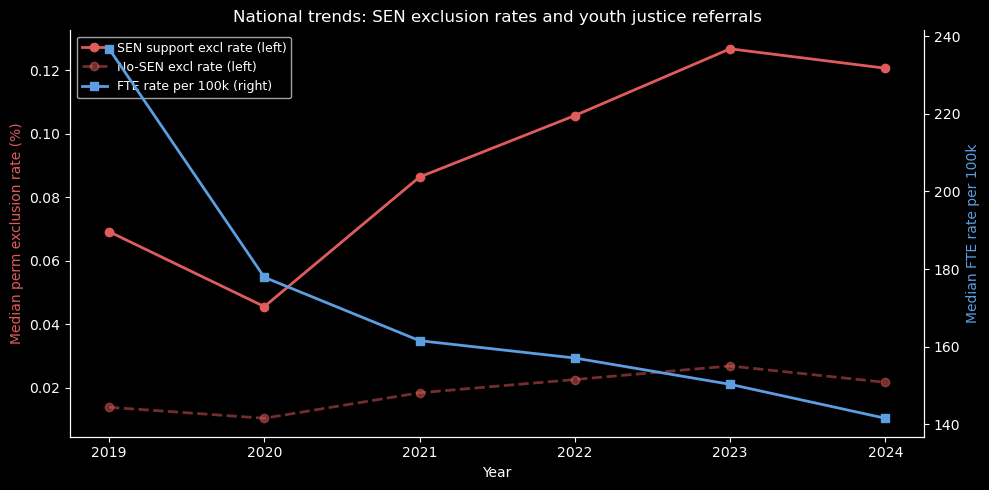

In [12]:
# Plot trends over time
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(trend['dfe_start_year'], trend['excl_sen'], 
         color=ACCENT, marker='o', linewidth=2, label='SEN support excl rate (left)')
ax1.plot(trend['dfe_start_year'], trend['excl_no_sen'], 
         color=ACCENT, marker='o', linewidth=2, linestyle='--', alpha=0.5, label='No-SEN excl rate (left)')
ax2.plot(trend['dfe_start_year'], trend['fte'], 
         color=ACCENT2, marker='s', linewidth=2, label='FTE rate per 100k (right)')

ax1.set_xlabel('Year')
ax1.set_ylabel('Median perm exclusion rate (%)', color=ACCENT)
ax2.set_ylabel('Median FTE rate per 100k', color=ACCENT2)
ax1.set_title('National trends: SEN exclusion rates and youth justice referrals', fontsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUTS / 'trends_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Clear finding 3: the outlier LAs — who bucks the trend?
# High exclusion AND high FTE vs high exclusion but low FTE

la_clean = la_avg.dropna(subset=['avg_excl_sen_support', 'avg_fte', 'imd'])

excl_median = la_clean['avg_excl_sen_support'].median()
fte_median = la_clean['avg_fte'].median()

# Quadrant labels
conditions = [
    (la_clean['avg_excl_sen_support'] >= excl_median) & (la_clean['avg_fte'] >= fte_median),
    (la_clean['avg_excl_sen_support'] >= excl_median) & (la_clean['avg_fte'] < fte_median),
    (la_clean['avg_excl_sen_support'] < excl_median)  & (la_clean['avg_fte'] >= fte_median),
    (la_clean['avg_excl_sen_support'] < excl_median)  & (la_clean['avg_fte'] < fte_median),
]
quadrant_labels = ['High excl / High FTE', 'High excl / Low FTE', 
                   'Low excl / High FTE', 'Low excl / Low FTE']
la_clean = la_clean.copy()
la_clean['quadrant'] = np.select(conditions, quadrant_labels)

print('LA counts by quadrant:')
print(la_clean['quadrant'].value_counts())
print()
print('High exclusion / Low FTE LAs (potential protective factors):')
print(la_clean[la_clean['quadrant'] == 'High excl / Low FTE']
      .sort_values('avg_excl_sen_support', ascending=False)
      [['la_name', 'avg_excl_sen_support', 'avg_fte', 'imd']]
      .head(10).to_string(index=False))
print()
print('Low exclusion / High FTE LAs (potential other pathways):')
print(la_clean[la_clean['quadrant'] == 'Low excl / High FTE']
      .sort_values('avg_fte', ascending=False)
      [['la_name', 'avg_excl_sen_support', 'avg_fte', 'imd']]
      .head(10).to_string(index=False))

LA counts by quadrant:
quadrant
High excl / Low FTE     30
Low excl / High FTE     30
High excl / High FTE    28
Low excl / Low FTE      28
Name: count, dtype: int64

High exclusion / Low FTE LAs (potential protective factors):
         la_name  avg_excl_sen_support    avg_fte    imd
        Barnsley              0.240431 165.721333 29.933
  North Tyneside              0.225139 132.487800 22.279
      Sunderland              0.216215 175.991500 30.586
   Wolverhampton              0.193199 170.497833 32.102
          Bolton              0.190864 172.476333 30.691
        Cornwall              0.186248 144.358500 23.072
           Wigan              0.178884 138.212500 25.713
       Gateshead              0.169806 151.529167 28.217
       Stockport              0.164269 152.513833 20.826
Stockton-on-Tees              0.162389 161.900167 25.790

Low exclusion / High FTE LAs (potential other pathways):
             la_name  avg_excl_sen_support    avg_fte    imd
       Isle of Wight      

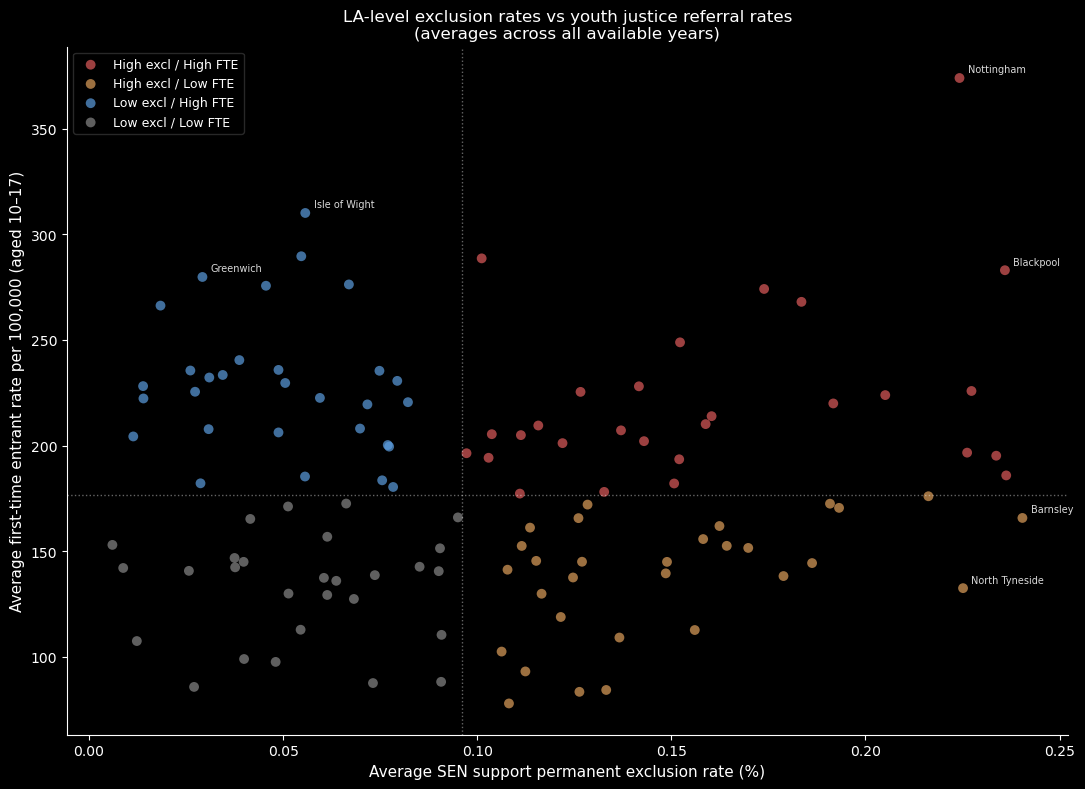

Saved: quadrant_scatter.png


In [14]:
# Quadrant scatter plot — annotate notable LAs
colours_q = {
    'High excl / High FTE': ACCENT,
    'High excl / Low FTE':  '#e0a05c',
    'Low excl / High FTE':  ACCENT2,
    'Low excl / Low FTE':   NEUTRAL,
}

fig, ax = plt.subplots(figsize=(11, 8))

for quadrant, group in la_clean.groupby('quadrant'):
    ax.scatter(group['avg_excl_sen_support'], group['avg_fte'],
               color=colours_q[quadrant], label=quadrant, alpha=0.7, s=50, edgecolors='none')

# Reference lines at medians
ax.axvline(excl_median, color='white', linestyle=':', alpha=0.4, linewidth=1)
ax.axhline(fte_median,  color='white', linestyle=':', alpha=0.4, linewidth=1)

# Annotate a few notable LAs
notable = ['Nottingham', 'Blackpool', 'Isle of Wight', 'Greenwich', 'North Tyneside', 'Barnsley']
for _, row in la_clean[la_clean['la_name'].isin(notable)].iterrows():
    ax.annotate(row['la_name'], (row['avg_excl_sen_support'], row['avg_fte']),
                textcoords='offset points', xytext=(6, 4), fontsize=7, alpha=0.85)

ax.set_xlabel('Average SEN support permanent exclusion rate (%)', fontsize=11)
ax.set_ylabel('Average first-time entrant rate per 100,000 (aged 10–17)', fontsize=11)
ax.set_title('LA-level exclusion rates vs youth justice referral rates\n(averages across all available years)', fontsize=12)
ax.legend(fontsize=9, framealpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUTS / 'quadrant_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: quadrant_scatter.png')

## Summary of Findings

**What the data clearly shows:**
- Children with SEN support are excluded at roughly **4–5x the rate** of non-SEN children. Children with EHC plans at **2–3x**. This is the inequality that motivates the project, and it's stark.
- Deprivation (IMD) is strongly correlated with both exclusion rates (r≈0.27) and youth justice referral rates (r≈0.42). It is the dominant predictor of both outcomes at LA level.

**What the data does not show (at this level of analysis):**
- A positive correlation between SEN exclusion rates and youth justice referral rates across LAs. The raw correlation is near-zero or slightly negative. Lagged correlations (up to 3 years) show the same.

**What this means:**

This is not evidence that exclusion is *irrelevant* to the youth justice pathway. It is evidence that **at LA aggregate level**, deprivation is the dominant driver of both outcomes. A high-deprivation LA excludes more SEN children *and* has more youth justice referrals — but those two things are both consequences of deprivation, not of each other.

This is a classic problem of ecological inference. The individual-level pathway (exclusion → reduced educational engagement → criminal justice contact) may be real and important, but it may not be visible when aggregated to 116 local authorities across six years.

The quadrant analysis is where it gets interesting: some LAs have high exclusion rates but low youth justice referrals — and vice versa. **Notebook 05 will investigate these outliers.** What are high-exclusion, low-FTE LAs doing differently? What's happening in low-exclusion, high-FTE LAs where other pathways seem to dominate?

**Next:** Notebook 04 — formal regression modelling, with deprivation as a control variable and a full examination of what the model can and cannot tell us.